In [2]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv("/Users/ashutoshpdy/Developer/GitHub Project (git clone)/MAA/MAA_Maternal-Awareness-Aid/mlops/data/raw/RS_Session_267_AU_2820_7.csv")
df.head(5)

,Sl. No.,State/UT,Public Hospitals - Count,Public Hospitals - Amount (In Crores),Private Hospitals - Count,Private Hospitals - Amount (In Crores)
0,1,Andaman and Nicobar Islands,8,0.01,2.0,0.00
1,2,Andhra Pradesh,660094,693.57,305840.0,404.17
2,3,Arunachal Pradesh,957,1.30,9.0,0.01
3,4,Assam,82154,97.84,5866.0,7.30
4,5,Bihar,33699,34.92,1268.0,0.99


In [8]:
df.info

<bound method DataFrame.info of     Sl. No.                                  State/UT  \
0         1               Andaman and Nicobar Islands   
1         2                            Andhra Pradesh   
2         3                         Arunachal Pradesh   
3         4                                     Assam   
4         5                                     Bihar   
5         6                                Chandigarh   
6         7                              Chhattisgarh   
7         8  Dadra and Nagar Haveli and Daman and Diu   
8         9                                   Gujarat   
9        10                                   Haryana   
10       11                          Himachal Pradesh   
11       12                         Jammu and Kashmir   
12       13                                 Jharkhand   
13       14                                 Karnataka   
14       15                                    Kerala   
15       16                                    Ladakh   

In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "")
    .str.replace("(", "")
    .str.replace(")", "")
)
df.columns

Index(['sl._no.', 'state/ut', 'public_hospitals__count',
       'public_hospitals__amount_in_crores', 'private_hospitals__count',
       'private_hospitals__amount_in_crores'],
      dtype='object')

In [14]:
df.isna().sum()

sl._no.                                0
state/ut                               0
public_hospitals__count                0
public_hospitals__amount_in_crores     0
private_hospitals__count               0
private_hospitals__amount_in_crores    0
dtype: int64

In [15]:
df.fillna(0, inplace=True)

In [17]:
df.columns

Index(['sl._no.', 'state/ut', 'public_hospitals__count',
       'public_hospitals__amount_in_crores', 'private_hospitals__count',
       'private_hospitals__amount_in_crores'],
      dtype='object')

In [18]:
numeric_cols = [
    "public_hospitals__count",
    "public_hospitals__amount_in_crores",
    "private_hospitals__count",
    "private_hospitals__amount_in_crores"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   sl._no.                              32 non-null     int64  
 1   state/ut                             32 non-null     object 
 2   public_hospitals__count              32 non-null     int64  
 3   public_hospitals__amount_in_crores   32 non-null     float64
 4   private_hospitals__count             32 non-null     float64
 5   private_hospitals__amount_in_crores  32 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 1.6+ KB


In [20]:
df["infrastructure_score"] = (
    df["public_hospitals__count"] * 0.4 +
    df["private_hospitals__count"] * 0.3 +
    df["public_hospitals__amount_in_crores"] * 0.2 +
    df["private_hospitals__amount_in_crores"] * 0.1
)

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["normalized_score"] = scaler.fit_transform(
    df[["infrastructure_score"]]
)

In [22]:
def risk_level(score):
    if score < 0.33:
        return "High Risk"
    elif score < 0.66:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_level"] = df["normalized_score"].apply(risk_level)

In [23]:
print(risk_level(0.1))   # Expected: High Risk
print(risk_level(0.5))   # Expected: Medium Risk
print(risk_level(0.9))   # Expected: Low Risk

High Risk
Medium Risk
Low Risk


In [24]:
df["risk_level"] = df["normalized_score"].apply(risk_level)

In [26]:
df[["state/ut", "normalized_score", "risk_level"]].head()

,state/ut,normalized_score,risk_level
0,Andaman and Nicobar Islands,0.000000,High Risk
1,Andhra Pradesh,0.966926,Low Risk
2,Arunachal Pradesh,0.001038,High Risk
3,Assam,0.094089,High Risk
4,Bihar,0.037658,High Risk


In [27]:
df["risk_level"].value_counts()

risk_level
High Risk      28
Low Risk        2
Medium Risk     2
Name: count, dtype: int64

In [28]:
test_scores = [0.0, 0.32, 0.33, 0.65, 0.66, 1.0]
for s in test_scores:
    print(s, "→", risk_level(s))

0.0 → High Risk
0.32 → High Risk
0.33 → Medium Risk
0.65 → Medium Risk
0.66 → Low Risk
1.0 → Low Risk


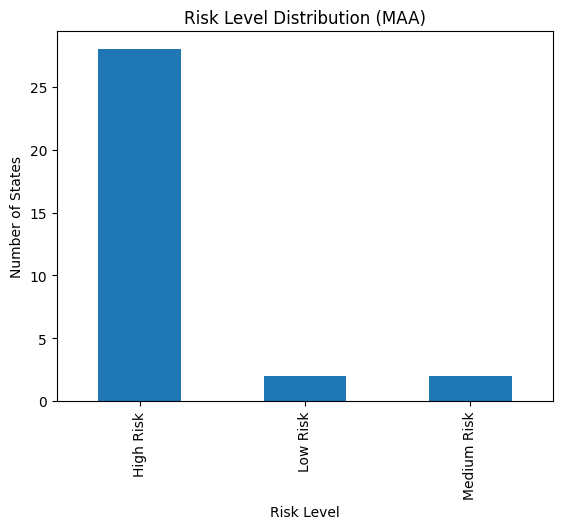

In [29]:
import matplotlib.pyplot as plt

df["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution (MAA)")
plt.xlabel("Risk Level")
plt.ylabel("Number of States")
plt.show()

In [30]:
output_path = "/Users/ashutoshpdy/Developer/GitHub Project (git clone)/MAA/MAA_Maternal-Awareness-Aid/mlops/data/processed/RS_Session_267_AU_2820_7.csv"
df.to_csv(output_path, index=False)

In [32]:
import os

os.path.exists("/Users/ashutoshpdy/Developer/GitHub Project (git clone)/MAA/MAA_Maternal-Awareness-Aid/mlops/data/processed/RS_Session_267_AU_2820_7.csv")

True